# ¡Hola Alexis!

Mi nombre es Israel, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

**Es un gusto acompañarte en este proceso, ¡empecemos!**

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [3]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [4]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [8]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [9]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 
- No hay presencia de valores nulos.
- El tipo de dato para cada columna es correcto en la mayoría de los casos:
  - Unicamente la columna `date` cuenta con un formato incorrecto, por lo que es necesario cambiar formato a fecha.

In [10]:
#Tranformar columna de date a formato de fecha
df['date'] = pd.to_datetime(df['date'],errors='coerce')

In [11]:
#Revisión de formato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [12]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [13]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [14]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [15]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [16]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted']==1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [17]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
categoricas = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']

for col in categoricas:
    print(f'{col}')
    print(df[col].describe())
    print(f'Categorías: {df[col].unique()}')
    print('')
    print(f'Distribución: {df[col].value_counts(normalize=True)}')
    print('')


Conteo de categorías:
landing
count     40000
unique        2
top           B
freq      20018
Name: landing, dtype: object
Categorías: ['A' 'B']

Distribución: B    0.50045
A    0.49955
Name: landing, dtype: float64

region
count     40000
unique        5
top       Norte
freq      11166
Name: region, dtype: object
Categorías: ['Norte' 'Occidente' 'Centro' 'Sur' 'Oriente']

Distribución: Norte        0.279150
Centro       0.240325
Sur          0.200975
Occidente    0.159950
Oriente      0.119600
Name: region, dtype: float64

dispositivo
count      40000
unique         2
top       Mobile
freq       24829
Name: dispositivo, dtype: object
Categorías: ['Mobile' 'Desktop']

Distribución: Mobile     0.620725
Desktop    0.379275
Name: dispositivo, dtype: float64

traffic_source
count       40000
unique          4
top       Organic
freq        17987
Name: traffic_source, dtype: object
Categorías: ['Email' 'Organic' 'Ads' 'Referral']

Distribución: Organic     0.449675
Ads         0.298375
Emai

✍️ **Comentario**:
- Todas las columnas muestran los valores esperados, con categorías bien escritas, sin presencia de errores de escritura o sentinels.
    - No hace falta realizar limpieza alguna en las columnas categóricas.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. La carga del archivo, la conversión de `date` a `datetime`, la revisión del rango temporal y el análisis descriptivo de `gasto` están correctamente realizados. Sin embargo, la validación de `user_id` solo muestra el número de valores únicos; falta comprobar explícitamente si existen identificadores duplicados con una validación de duplicados. Además, la lista de variables categóricas no incluye `converted`, por lo que no se confirma que esta columna contenga únicamente los valores 0 y 1.

</div>


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [18]:
# Gasto por versión
gasto_A = df[(df['landing']=='A') & (df['converted']==1)]['gasto']
gasto_B = df[(df['landing']=='B') & (df['converted']==1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba T de Student

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencia significativa entre el promedio de gasto del grupo A y el promedio de gasto del gupo B.
- **Hipótesis alternativa (H₁):** Existe evidencia estadística para afirmar diferencia significativa entre el promedio de gasto del grupo A y del grupo B.

In [19]:
#Prueba de varianzas
from scipy.stats import levene

l_stat, p_value_var = levene(gasto_A,gasto_B)

print(f'Estadístico de Levene: {l_stat}')
print(f'Valor p: {p_value_var}')

Estadístico de Levene: 29.17646453202917
Valor p: 6.875301988016449e-08


Las varianzas de ambos grupos son distintas, por lo que se debe de establecer el parémetro equal_var=False

In [20]:
# Aplicar prueba
t_stat, valor_p = ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {valor_p}")

Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


In [32]:
#Comparar promedios
df[df['converted']==1].groupby('landing')['gasto'].mean()

landing
A    61.086572
B    68.745360
Name: gasto, dtype: float64

### 📝 Conclusión e interpretación

**Decisión:**  
Debido a que el valor p de la prueba arroja un valor menor al nivel de significancia de 0.05, entonces se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Rechazar la hipótesis nula significa que existe evidencia estadística para afirmar que existe una diferencia entre el promedio de gasto del grupo A y el promedio de gasto del grupo B.


---

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente trabajo. Filtraste correctamente a los usuarios convertidos, aplicaste la prueba de Levene y utilizaste su resultado para justificar `equal_var=False` en la prueba t de Welch. Los promedios obtenidos para A y B son consistentes con lo esperado y la decisión de rechazar H₀ está correctamente sustentada.

</div>



## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en ambas páginas. Cualquier diferencia se debe al azar del muestreo.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre ambas páginas. Hay un factor que influye en la decisión de compra.

In [36]:
# Número de usuarios convertidos por página
conversion = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversion)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [39]:
print(conversion/totales)

landing
A    0.125713
B    0.159556
Name: converted, dtype: float64


In [37]:
#Transformar a formato de lista
exitos = [conversion['A'],conversion['B']]
observaciones = [totales['A'],totales['B']]

In [23]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos,observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Debido a que el test arrojó un valor p menor al nivel de significancia de 0.05, se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Hay evidencia estadística para afirmar que existe una diferencia entre la tasa de conversión del grupo A y el grupo B.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente trabajo. Calculaste correctamente las conversiones y observaciones por página, aplicaste la prueba z de dos proporciones y obtuviste una decisión consistente con el p-value. Las tasas de A y B también están correctamente calculadas. En la conclusión, expresa la diferencia como aproximadamente 3.38 puntos porcentuales, no solo como 3.5%, porque se trata de la resta entre dos tasas de conversión.

</div>


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrado

**Hipótesis:**
- Hipótesis nula (H₀): No existe relación entre las dos variables (son independientes).
- Hipótesis alternativa (H₁): Sí existe una relación entre las dos variables (no son independientes).

In [24]:
# Aplicar prueba
tabla = pd.crosstab(df['traffic_source'],df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [25]:
chi_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f'Chi-cuadrado: {chi_stat}')
print(f'Valor p: {p_value}')
print(f'Grados de libertad: {dof}')
print('Frecuencias esperadas:')
print(expected)

Chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914
Grados de libertad: 3
Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula debido a que se obtuvo un valor p menor al nivel de significancia de 0.05

**Interpretación de negocio:**  
Existe evidencia estadística para afirmar que existe relación entre el canal de tráfico y la conversión.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. La tabla de contingencia y la prueba chi-cuadrada entre `traffic_source` y `converted` están correctamente construidas, y la decisión de rechazar H₀ coincide con el resultado. Sin embargo, dentro de este paso falta mostrar la tabla normalizada por fila, necesaria para comparar las tasas de conversión de cada canal y no solo sus volúmenes absolutos. Esa tabla permitiría sustentar con precisión que Email presenta la tasa más alta, seguida de Ads, aunque las diferencias sean pequeñas.

</div>


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrado

**Hipótesis:**
- Hipótesis nula (H₀): No existe relación entre las dos variables (son independientes)
- Hipótesis alternativa (H₁): Sí existe una relación entre las dos variables (no son independientes).

In [26]:
# Aplicar prueba
tabla2 = pd.crosstab(df['user_type'],df['converted'])
tabla2

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [27]:
chi_stat2, p_value2, dof2, expected2 = chi2_contingency(tabla2)

print(f'Chi-cuadrado: {chi_stat2}')
print(f'Valor p: {p_value2}')
print(f'Grados de libertad: {dof2}')
print('Frecuencias esperadas:')
print(expected2)

Chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974
Grados de libertad: 1
Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


### 📝 Conclusión e interpretación

**Decisión:**  
Se acepta la hipótesis nula, debido a que la prueba arrojó un valor p mayor al nivel de significancia de 0.05.

**Interpretación de negocio:**  
No existe relación entre el tipo de usuario y la conversión.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. La tabla de contingencia y la prueba chi-cuadrada para `user_type` están correctamente aplicadas, y la decisión de no rechazar H₀ es coherente con el p-value obtenido. Sin embargo, igual que en el paso anterior, falta incluir aquí la tabla normalizada por fila para mostrar las tasas de conversión de usuarios nuevos y recurrentes.

</div>


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

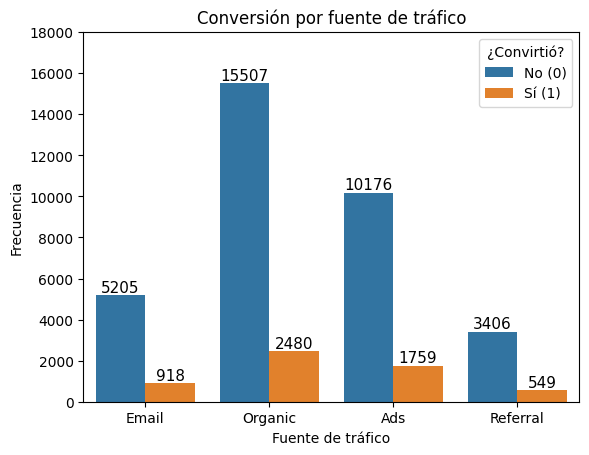

In [28]:
fig1 = sns.countplot(data=df, x='traffic_source', hue='converted')

for bar in fig1.patches:
    height = bar.get_height()
    fig1.text(x=bar.get_x()+bar.get_width() /2,
              y=height,
              s=height,
              ha='center',
              va='bottom',
              fontsize=11)

plt.title('Conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Frecuencia')
plt.ylim(0,18000)
plt.legend(title='¿Convirtió?', labels = ['No (0)', 'Sí (1)'])
plt.show()


✍️ **Comentario**: 
La fuente de tráfico orgánica destaca por ser la que más aporta tanto a las interacciones con el sitio web como en la cantidad de conversiones, seguida de cerca por los anuncios. Aunque ambas fuentes de tráfico destacan por la cantidad de conversiones, habrá que analizar las tasas de conversión para evaluar su efectividad.

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


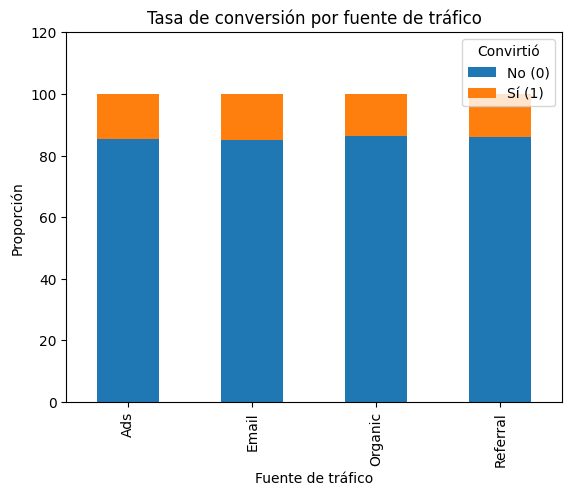

In [29]:

tabla = pd.crosstab(df['traffic_source'],df['converted'],normalize='index') * 100
print(tabla)

tabla.plot(kind='bar',stacked=True)
plt.title('Tasa de conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Proporción')
plt.ylim(0,120)
plt.legend(title='Convirtió',labels=['No (0)','Sí (1)'],loc='upper right',bbox_to_anchor=(1,1))
plt.show()


✍️ **Comentario**: 
Al analizar las tasas de conversión de las cuatro fuentes de tráfico, nos encontramos con proporciones bastante similares, en las que las cuatro mantienen una tasa de conversión menor al 20%.

### Relación entre el tipo de usuario y la conversión

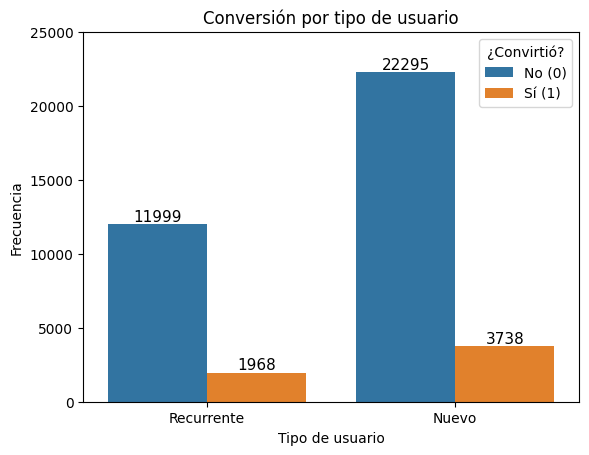

In [30]:
fig2 = sns.countplot(data=df, x='user_type', hue='converted')

for bar in fig2.patches:
    height = bar.get_height()
    fig2.text(x=bar.get_x()+bar.get_width() /2,
              y=height,
              s=height,
              ha='center',
              va='bottom',
              fontsize=11)

plt.title('Conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Frecuencia')
plt.ylim(0,25000)
plt.legend(title='¿Convirtió?', labels = ['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: 
Los usuarios nuevos superan e los recurrentes en números tanto de interacciones como de conversiones, pero para entender la foto completa, habrá que analizar las atsas de conversión para determinar que tipo de usuario es más eficiente.

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


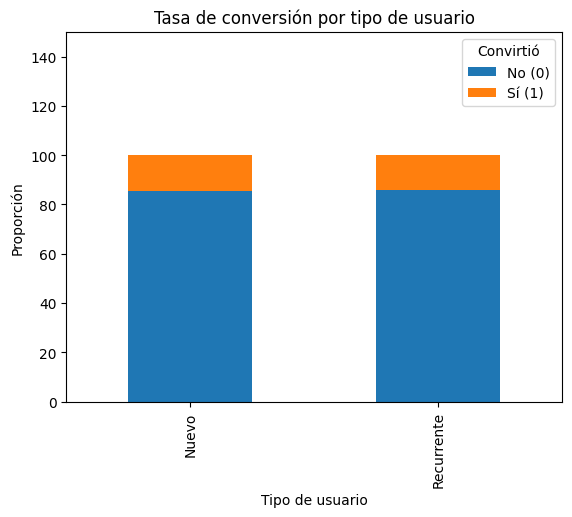

In [31]:
tabla = pd.crosstab(df['user_type'],df['converted'],normalize='index') * 100
print(tabla)

tabla.plot(kind='bar',stacked=True)
plt.title('Tasa de conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Proporción')
plt.ylim(0,150)
plt.legend(title='Convirtió',labels=['No (0)','Sí (1)'],loc='upper right',bbox_to_anchor=(1,1))
plt.show()


✍️ **Comentario**:
Nuevamente no se muestra a la vista una diferencia entre las tasas de conversión de ambos grupos de usuarios. Ambos tipos mustran una tasa de conversión menor al 20%.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente trabajo. Incluiste las cuatro visualizaciones solicitadas: conteos y proporciones para `traffic_source` y `user_type`. Las tablas normalizadas utilizadas en los gráficos son correctas y las interpretaciones distinguen adecuadamente entre volumen absoluto y tasa de conversión. Como mejora menor, especifica los porcentajes más relevantes en los comentarios para que la lectura no dependa únicamente de la gráfica.

</div>


## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Al revisar los resultados de las pruebas se concluye que existe evidencia estadística de una diferencia entre promedios de gasto. Al comparar los promedios, de observa que el tipo de página B efectivamente tiene un promedio de gasto mayor que el tipo de página B, con una diferencia de 7.66.

En los canales de tráfico se encontró evidencia estadística de diferencias entre las tasas de conversión por canales de tráfico. Al observar dichas tasas y la visualización en gráfico se muestran diferencias muy pequeñas, por lo que no parece haber información estadística que sugiera una inversión dirigida hacia alguno de los canales.

Según la prueba realizada, no existe evidencia estadística que sugiera relación entre el tipo de usuario y la tasa de conversión, cosa que se confirma al comparar las tasas de conversión lado a lado.

Basandonos en estos hallazgos, lo mejor sería continuar con la nueva versión del sitio web, ya que este cambio impulsaría un aumento en el promedio de gasto de aproximadamente un 12.5%. En cuanto a la estrategia de marketing, no se muestra un cambio muy llamativo en cuanto a los canales de tráfico, por lo que no existe razón alguna para enfocar la estrategia de marketing actual en algun canal  específico.

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Existe evidencia estadítica que sugiera una diferencia entre los promedios  de gasto de ambos grupos.
- Los datos muestran una diferencia de promedios de 12.5%
- **Interpretación:**
Según las pruebas realizadas y la comparación de promedios, la nueva página B utilizada tiene un promedio de gasto más alto que la página A de control.
<br>

**Tasa de conversión:** 
- Existe evidencia estadística para afirmar una diferencia en la tasa de conversión del grupo A y el grupo B.
- Las tasas de conversión del grupo A y B son 12.5% y 16% respectivamente.
- **Interpretación:**
Según los resultados de la prueba Z de proporciones, existe evidencia estadística que apunta a una diferencia en las tasas de conversión de ambos grupos. Al revisar ambas tasas se muestra una diferencia de 3.5 puntos porcentuales.
---

#### 📊 **Segmentación por fuente de tráfico**
- Existe evidencia estadística para afirmar relación entre la fuente de tráfico y la conversión de los clientes.
- **Interpretación:**
 A pesar de la confirmación de una relación, si se comparan las tasas de conversión entre canales de tráfico, el cambio es muy pequeño, por lo que no debería influir en la estrategia de marketing actual.
 ---

#### 📊 **Segmentación por tipo de usuario**
- No existe evidencia estadística para afirmar relación entre el tipo de usuario y la conversión.
- **Interpretación:**
Debido a la falta de correlación, se concluye que el tipo de usuario no debe ser tomado en cuenta para las estrategias de marketing que se pretenden implementar.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Continuar con la nueva versión del sitio web, ya que este cambio impulsaría un aumento en el promedio de gasto de aproximadamente un 12.5%. 
- En cuanto a la estrategia de marketing, no se muestra un cambio muy llamativo en cuanto a los canales de tráfico, por lo que no existe razón alguna para enfocar la estrategia de marketing actual en algun canal específico.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Felicitaciones, los hallazgos son claros y directos. Esto es muy importante
para cualquier analista de datos, ya que no alcanza solo con obtener números, también debemos ser
capaces de comunicar cómo esos números impactan en el negocio.

Felicitaciones por el trabajo realizado. Si bien hay algunos puntos de mejora, el proyecto está en
condiciones de ser aprobado.

¡Mucho éxito en tu camino dentro del mundo de los datos!


</div>